In [47]:
!pip -q install datasets transformers evaluate accelerate scikit-learn

In [48]:
import re
import time
import random
import numpy as np
import pandas as pd
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from sklearn.metrics import accuracy_score, classification_report, f1_score

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed
)
import evaluate
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [49]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# 1. Load dataset

In [50]:
dataset = load_dataset("emotion")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [51]:
print(dataset["train"][0])
print(dataset["train"].features)

{'text': 'i didnt feel humiliated', 'label': 0}
{'text': Value('string'), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}


In [52]:
label_names = dataset["train"].features["label"].names
num_classes = len(label_names)

print("Label names:", label_names)
print("Number of classes:", num_classes)

Label names: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Number of classes: 6


In [53]:
train_texts = dataset["train"]["text"]
val_texts   = dataset["validation"]["text"]
test_texts  = dataset["test"]["text"]

train_labels = dataset["train"]["label"]
val_labels   = dataset["validation"]["label"]
test_labels  = dataset["test"]["label"]

print("Train size:", len(train_texts))
print("Validation size:", len(val_texts))
print("Test size:", len(test_texts))

Train size: 16000
Validation size: 2000
Test size: 2000


## 1.1 Exploratory Data Analysis (EDA)

,Split,Samples
0,Train,16000
1,Validation,2000
2,Test,2000


split,test,train,validation
label_name,,,
sadness,581,4666,550
joy,695,5362,704
love,159,1304,178
anger,275,2159,275
fear,224,1937,212
surprise,66,572,81


num_words            num_chars            
                mean median max      mean median  max
split                                                
test           19.15   17.0  61     96.59   86.0  296
train          19.17   17.0  66     96.85   86.0  300
validation     18.87   17.0  61     95.35   85.0  295

,label_name,avg_words_train
0,sadness,18.36
1,joy,19.50
2,love,20.70
3,anger,19.23
4,fear,18.84
5,surprise,19.97


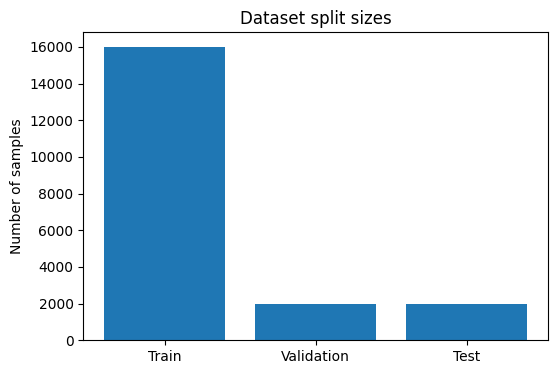

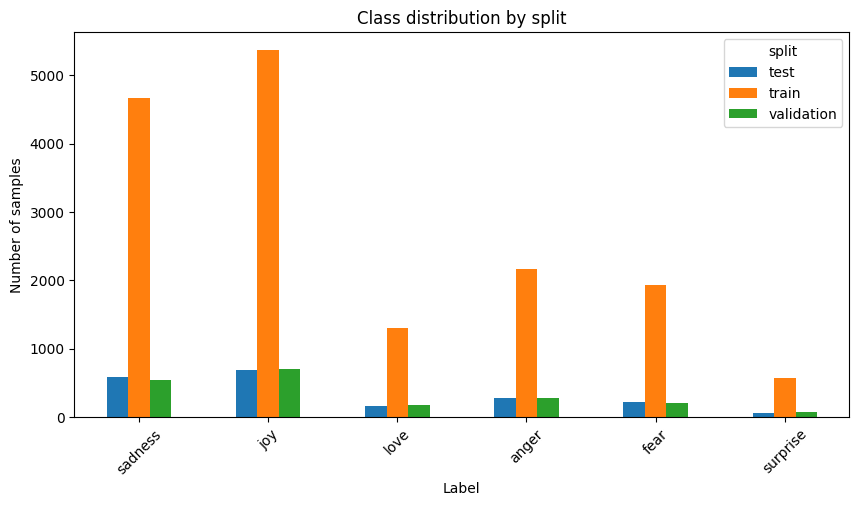

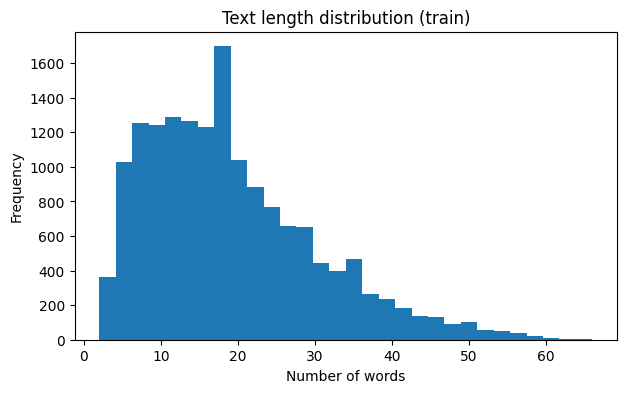

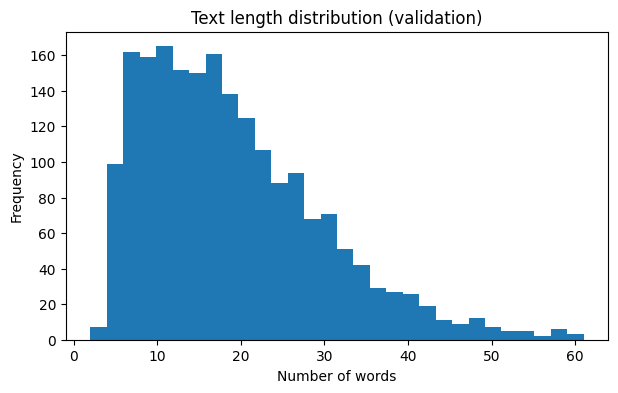

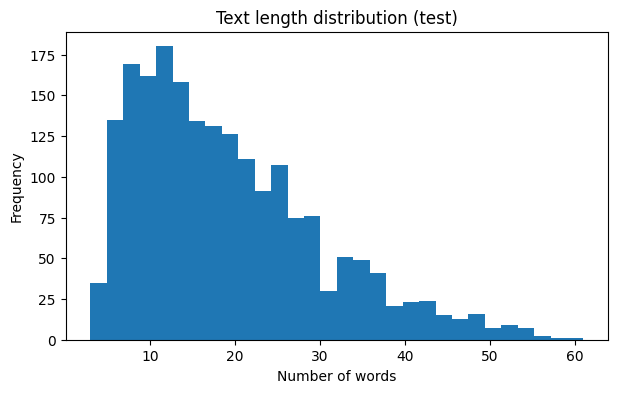

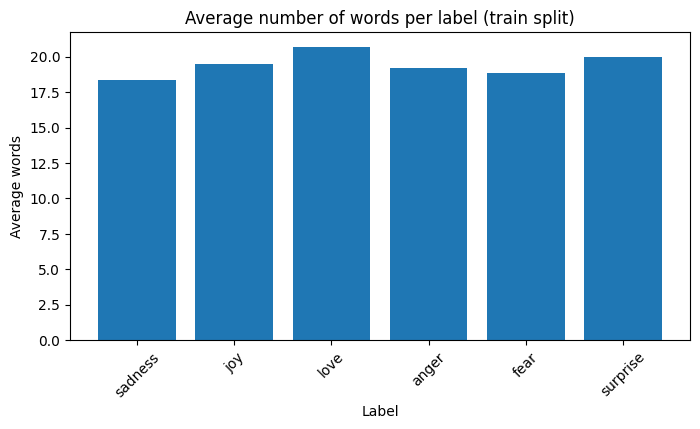

In [54]:
split_sizes_df = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Samples": [len(dataset["train"]), len(dataset["validation"]), len(dataset["test"])]
})
display(split_sizes_df)

def build_split_eda(split_name):
    split = dataset[split_name]
    texts = split["text"]
    labels = split["label"]
    return pd.DataFrame({
        "split": split_name,
        "text": texts,
        "label_id": labels,
        "label_name": [label_names[label] for label in labels],
        "num_words": [len(str(text).split()) for text in texts],
        "num_chars": [len(str(text)) for text in texts]
    })

eda_df = pd.concat(
    [build_split_eda("train"), build_split_eda("validation"), build_split_eda("test")],
    ignore_index=True
)

label_distribution_df = (
    eda_df.groupby(["split", "label_name"])
    .size()
    .reset_index(name="count")
)
label_distribution_pivot = (
    label_distribution_df.pivot(index="label_name", columns="split", values="count")
    .fillna(0)
    .astype(int)
    .reindex(label_names)
)
display(label_distribution_pivot)

length_summary_df = (
    eda_df.groupby("split")[["num_words", "num_chars"]]
    .agg(["mean", "median", "max"])
    .round(2)
)
display(length_summary_df)

avg_words_by_label_df = (
    eda_df[eda_df["split"] == "train"]
    .groupby("label_name")["num_words"]
    .mean()
    .reindex(label_names)
    .round(2)
    .reset_index(name="avg_words_train")
)
display(avg_words_by_label_df)

plt.figure(figsize=(6, 4))
plt.bar(split_sizes_df["Split"], split_sizes_df["Samples"])
plt.title("Dataset split sizes")
plt.ylabel("Number of samples")
plt.show()

label_distribution_pivot.plot(kind="bar", figsize=(10, 5))
plt.title("Class distribution by split")
plt.xlabel("Label")
plt.ylabel("Number of samples")
plt.xticks(rotation=45)
plt.show()

for split_name in ["train", "validation", "test"]:
    plt.figure(figsize=(7, 4))
    subset = eda_df.loc[eda_df["split"] == split_name, "num_words"]
    plt.hist(subset, bins=30)
    plt.title(f"Text length distribution ({split_name})")
    plt.xlabel("Number of words")
    plt.ylabel("Frequency")
    plt.show()

plt.figure(figsize=(8, 4))
plt.bar(avg_words_by_label_df["label_name"], avg_words_by_label_df["avg_words_train"])
plt.title("Average number of words per label (train split)")
plt.xlabel("Label")
plt.ylabel("Average words")
plt.xticks(rotation=45)
plt.show()

# 2. CNN approach
Clean text, build vocabulary, convert sentences to token id sequences, pad to same length, and use TextCNN for classification.

## 2.1 Preprocessing for CNN

In [55]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text):
    return text.split()

train_texts_cnn = [clean_text(t) for t in train_texts]
val_texts_cnn   = [clean_text(t) for t in val_texts]
test_texts_cnn  = [clean_text(t) for t in test_texts]

print(train_texts_cnn[0])

i didnt feel humiliated


## 2.2 Create vocabulary

In [56]:
counter = Counter()
for text in train_texts_cnn:
    counter.update(tokenize(text))

max_vocab_size = 20000
special_tokens = ["<PAD>", "<UNK>"]

most_common = counter.most_common(max_vocab_size - len(special_tokens))
vocab = {tok: idx for idx, tok in enumerate(special_tokens)}

for word, _ in most_common:
    vocab[word] = len(vocab)

print("Vocabulary size:", len(vocab))
print("Sample vocab items:", list(vocab.items())[:10])

Vocabulary size: 15214
Sample vocab items: [('<PAD>', 0), ('<UNK>', 1), ('i', 2), ('feel', 3), ('and', 4), ('to', 5), ('the', 6), ('a', 7), ('feeling', 8), ('that', 9)]


## 2.3 Encode and Padding

In [57]:
def encode_text(text, vocab):
    return [vocab.get(tok, vocab["<UNK>"]) for tok in tokenize(text)]

train_encoded = [encode_text(t, vocab) for t in train_texts_cnn]
val_encoded   = [encode_text(t, vocab) for t in val_texts_cnn]
test_encoded  = [encode_text(t, vocab) for t in test_texts_cnn]

lengths = [len(x) for x in train_encoded]
max_len = min(50, max(lengths))

print("Max sequence length for CNN:", max_len)
print("Min length:", min(lengths))
print("Mean length:", round(sum(lengths) / len(lengths), 2))

Max sequence length for CNN: 50
Min length: 2
Mean length: 19.17


In [58]:
def pad_sequence(seq, max_len, pad_value=0):
    if len(seq) < max_len:
        seq = seq + [pad_value] * (max_len - len(seq))
    else:
        seq = seq[:max_len]
    return seq

train_padded = [pad_sequence(x, max_len) for x in train_encoded]
val_padded   = [pad_sequence(x, max_len) for x in val_encoded]
test_padded  = [pad_sequence(x, max_len) for x in test_encoded]

## 2.4 Dataset và DataLoader

In [59]:
class EmotionCNNDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = torch.tensor(texts, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

train_ds_cnn = EmotionCNNDataset(train_padded, train_labels)
val_ds_cnn   = EmotionCNNDataset(val_padded, val_labels)
test_ds_cnn  = EmotionCNNDataset(test_padded, test_labels)

train_loader_cnn = DataLoader(train_ds_cnn, batch_size=64, shuffle=True)
val_loader_cnn   = DataLoader(val_ds_cnn, batch_size=64)
test_loader_cnn  = DataLoader(test_ds_cnn, batch_size=64)

## 2.5 Build Model TextCNN

In [60]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, filter_sizes=[3,4,5], num_filters=100, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=fs)
            for fs in filter_sizes
        ])

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(filter_sizes), num_classes)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)

        conv_outs = []
        for conv in self.convs:
            c = F.relu(conv(x))
            p = F.max_pool1d(c, kernel_size=c.shape[2]).squeeze(2)
            conv_outs.append(p)

        out = torch.cat(conv_outs, dim=1)
        out = self.dropout(out)
        out = self.fc(out)
        return out

## 2.6 Training and Evaluation for CNN

In [61]:
def train_one_epoch_cnn(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

@torch.no_grad()
def evaluate_cnn(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    return total_loss / len(loader), acc, f1, all_labels, all_preds

In [62]:
cnn_model = TextCNN(
    vocab_size=len(vocab),
    embed_dim=128,
    num_classes=num_classes,
    filter_sizes=[3,4,5],
    num_filters=100,
    dropout=0.5
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)

num_epochs_cnn = 8
best_val_acc_cnn = 0
cnn_history = []

start_time_cnn = time.time()

for epoch in range(num_epochs_cnn):
    train_loss = train_one_epoch_cnn(cnn_model, train_loader_cnn, optimizer, criterion, device)
    val_loss, val_acc, val_f1, _, _ = evaluate_cnn(cnn_model, val_loader_cnn, criterion, device)

    cnn_history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "val_f1_macro": val_f1
    })

    print(f"Epoch {epoch+1}/{num_epochs_cnn}")
    print(f"  Train loss: {train_loss:.4f}")
    print(f"  Val loss:   {val_loss:.4f}")
    print(f"  Val acc:    {val_acc:.4f}")
    print(f"  Val f1:     {val_f1:.4f}")

    if val_acc > best_val_acc_cnn:
        best_val_acc_cnn = val_acc
        torch.save(cnn_model.state_dict(), "best_textcnn.pt")

cnn_train_time = time.time() - start_time_cnn
print(f"\nCNN training time: {cnn_train_time:.2f} seconds")

Epoch 1/8
  Train loss: 1.5752
  Val loss:   1.3304
  Val acc:    0.5190
  Val f1:     0.2991
Epoch 2/8
  Train loss: 1.1246
  Val loss:   0.7726
  Val acc:    0.7260
  Val f1:     0.6264
Epoch 3/8
  Train loss: 0.6070
  Val loss:   0.4318
  Val acc:    0.8620
  Val f1:     0.8271
Epoch 4/8
  Train loss: 0.3508
  Val loss:   0.3375
  Val acc:    0.8765
  Val f1:     0.8475
Epoch 5/8
  Train loss: 0.2337
  Val loss:   0.2949
  Val acc:    0.8930
  Val f1:     0.8620
Epoch 6/8
  Train loss: 0.1697
  Val loss:   0.2800
  Val acc:    0.9030
  Val f1:     0.8761
Epoch 7/8
  Train loss: 0.1390
  Val loss:   0.2754
  Val acc:    0.9040
  Val f1:     0.8795
Epoch 8/8
  Train loss: 0.1108
  Val loss:   0.2873
  Val acc:    0.9065
  Val f1:     0.8823

CNN training time: 17.96 seconds


In [63]:
cnn_history_df = pd.DataFrame(cnn_history)
cnn_history_df

,epoch,train_loss,val_loss,val_accuracy,val_f1_macro
0,1,1.575177,1.330436,0.5190,0.299062
1,2,1.124585,0.772581,0.7260,0.626392
2,3,0.607029,0.431818,0.8620,0.827100
3,4,0.350773,0.337477,0.8765,0.847474
4,5,0.233749,0.294949,0.8930,0.861981
5,6,0.169702,0.280041,0.9030,0.876058
6,7,0.138964,0.275381,0.9040,0.879512
7,8,0.110835,0.287256,0.9065,0.882313


## 2.7 Validation and Test for CNN

In [64]:
cnn_model.load_state_dict(torch.load("best_textcnn.pt", map_location=device))

cnn_test_loss, cnn_test_acc, cnn_test_f1, cnn_y_true, cnn_y_pred = evaluate_cnn(
    cnn_model, test_loader_cnn, criterion, device
)

print("CNN Test loss:", round(cnn_test_loss, 4))
print("CNN Test accuracy:", round(cnn_test_acc, 4))
print("CNN Test macro F1:", round(cnn_test_f1, 4))

CNN Test loss: 0.2824
CNN Test accuracy: 0.897
CNN Test macro F1: 0.8477


In [65]:
print(classification_report(cnn_y_true, cnn_y_pred, target_names=label_names))

              precision    recall  f1-score   support

     sadness       0.95      0.92      0.93       581
         joy       0.92      0.92      0.92       695
        love       0.71      0.88      0.78       159
       anger       0.90      0.89      0.90       275
        fear       0.87      0.87      0.87       224
    surprise       0.77      0.61      0.68        66

    accuracy                           0.90      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.90      0.90      0.90      2000



## 2.8 Testing CNN with new sentences

In [66]:
def predict_text_cnn(text, model, vocab, max_len, label_names, device):
    model.eval()
    text = clean_text(text)
    encoded = encode_text(text, vocab)
    padded = pad_sequence(encoded, max_len)

    x = torch.tensor([padded], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = model(x)
        pred = torch.argmax(logits, dim=1).item()

    return label_names[pred]

samples = [
    "I am feeling great and excited today",
    "I am really scared about tomorrow",
    "I miss my friends and feel lonely"
]

for s in samples:
    print(s, "->", predict_text_cnn(s, cnn_model, vocab, max_len, label_names, device))

I am feeling great and excited today -> joy
I am really scared about tomorrow -> fear
I miss my friends and feel lonely -> sadness


# 3. RNN approach (BiLSTM)

This section builds a **full RNN pipeline** for text classification using a **BiLSTM** model.

The pipeline is kept separate from the CNN section:
1. Clean text for the RNN branch
2. Build RNN vocabulary
3. Encode and pad sequences
4. Create RNN `Dataset` and `DataLoader`
5. Train and evaluate a **BiLSTM** baseline
6. Test the model on new sentences

## 3.1 Preprocessing for RNN

We apply the same cleaning logic as before, but create a **separate set of variables** for the RNN pipeline so the section is self-contained.

In [67]:
def build_vocab(texts, min_freq=2, max_vocab_size=20000):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))

    vocab = {"<PAD>": 0, "<UNK>": 1}
    for word, freq in counter.most_common():
        if freq < min_freq:
            continue
        if len(vocab) >= max_vocab_size:
            break
        vocab[word] = len(vocab)

    return vocab

#preprocessing pipeline for the RNN branch
train_texts_rnn = [clean_text(text) for text in train_texts]
val_texts_rnn = [clean_text(text) for text in val_texts]
test_texts_rnn = [clean_text(text) for text in test_texts]

rnn_vocab = build_vocab(train_texts_rnn, min_freq=2)
rnn_max_len = max(len(text.split()) for text in train_texts_rnn)

X_train_rnn = [pad_sequence(encode_text(text, rnn_vocab), rnn_max_len) for text in train_texts_rnn]
X_val_rnn = [pad_sequence(encode_text(text, rnn_vocab), rnn_max_len) for text in val_texts_rnn]
X_test_rnn = [pad_sequence(encode_text(text, rnn_vocab), rnn_max_len) for text in test_texts_rnn]

print("RNN vocab size:", len(rnn_vocab))
print("RNN max_len:", rnn_max_len)
print("Sample encoded sequence length:", len(X_train_rnn[0]))


RNN vocab size: 7401
RNN max_len: 66
Sample encoded sequence length: 66


## 3.2 Dataset and DataLoader for RNN

Create dedicated `Dataset` and `DataLoader` objects for the BiLSTM model.

In [68]:
class TextDatasetRNN(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = torch.tensor(self.sequences[idx], dtype=torch.long)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return seq, label

train_dataset_rnn = TextDatasetRNN(X_train_rnn, train_labels)
val_dataset_rnn = TextDatasetRNN(X_val_rnn, val_labels)
test_dataset_rnn = TextDatasetRNN(X_test_rnn, test_labels)

train_loader_rnn = DataLoader(train_dataset_rnn, batch_size=64, shuffle=True)
val_loader_rnn = DataLoader(val_dataset_rnn, batch_size=64)
test_loader_rnn = DataLoader(test_dataset_rnn, batch_size=64)

print("RNN train batches:", len(train_loader_rnn))
print("RNN val batches:", len(val_loader_rnn))
print("RNN test batches:", len(test_loader_rnn))

RNN train batches: 250
RNN val batches: 32
RNN test batches: 32


## 3.3 Build BiLSTM model

In [69]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, num_layers=1, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        x = self.embedding(x)                 # [B, T, E]
        _, (h_n, _) = self.lstm(x)            # h_n: [num_layers*2, B, H]
        h_fw = h_n[-2]                        # forward last layer
        h_bw = h_n[-1]                        # backward last layer
        h = torch.cat([h_fw, h_bw], dim=1)    # [B, 2H]
        h = self.dropout(h)
        return self.fc(h)


## 3.4 Train and validate BiLSTM

In [70]:
bilstm_model = BiLSTMClassifier(
    vocab_size=len(rnn_vocab),
    embed_dim=128,
    hidden_dim=128,
    num_classes=num_classes,
    num_layers=1,
    dropout=0.5
).to(device)

bilstm_criterion = nn.CrossEntropyLoss()
bilstm_optimizer = torch.optim.Adam(bilstm_model.parameters(), lr=1e-3)

num_epochs_bilstm = 8
best_val_acc_bilstm = 0
bilstm_history = []

start_time_bilstm = time.time()

for epoch in range(num_epochs_bilstm):
    train_loss = train_one_epoch_cnn(bilstm_model, train_loader_rnn, bilstm_optimizer, bilstm_criterion, device)
    val_loss, val_acc, val_f1, _, _ = evaluate_cnn(bilstm_model, val_loader_rnn, bilstm_criterion, device)

    bilstm_history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "val_f1_macro": val_f1
    })

    print(f"Epoch {epoch+1}/{num_epochs_bilstm}")
    print(f"  Train loss: {train_loss:.4f}")
    print(f"  Val loss:   {val_loss:.4f}")
    print(f"  Val acc:    {val_acc:.4f}")
    print(f"  Val f1:     {val_f1:.4f}")

    if val_acc > best_val_acc_bilstm:
        best_val_acc_bilstm = val_acc
        torch.save(bilstm_model.state_dict(), "best_bilstm.pt")

bilstm_train_time = time.time() - start_time_bilstm
print(f"\nBiLSTM training time: {bilstm_train_time:.2f} seconds")

Epoch 1/8
  Train loss: 1.5239
  Val loss:   1.3237
  Val acc:    0.5120
  Val f1:     0.2282
Epoch 2/8
  Train loss: 1.0200
  Val loss:   0.7980
  Val acc:    0.7210
  Val f1:     0.5441
Epoch 3/8
  Train loss: 0.6028
  Val loss:   0.5455
  Val acc:    0.8125
  Val f1:     0.7409
Epoch 4/8
  Train loss: 0.3870
  Val loss:   0.4387
  Val acc:    0.8570
  Val f1:     0.8119
Epoch 5/8
  Train loss: 0.2792
  Val loss:   0.4148
  Val acc:    0.8650
  Val f1:     0.8220
Epoch 6/8
  Train loss: 0.2033
  Val loss:   0.3729
  Val acc:    0.8860
  Val f1:     0.8514
Epoch 7/8
  Train loss: 0.1533
  Val loss:   0.3627
  Val acc:    0.8905
  Val f1:     0.8566
Epoch 8/8
  Train loss: 0.1234
  Val loss:   0.3843
  Val acc:    0.8865
  Val f1:     0.8470

BiLSTM training time: 66.40 seconds


In [71]:
bilstm_history_df = pd.DataFrame(bilstm_history)
bilstm_history_df

,epoch,train_loss,val_loss,val_accuracy,val_f1_macro
0,1,1.523913,1.323738,0.5120,0.228172
1,2,1.020020,0.797981,0.7210,0.544076
2,3,0.602767,0.545511,0.8125,0.740899
3,4,0.386981,0.438696,0.8570,0.811915
4,5,0.279203,0.414792,0.8650,0.822021
5,6,0.203258,0.372863,0.8860,0.851396
6,7,0.153313,0.362714,0.8905,0.856647
7,8,0.123391,0.384254,0.8865,0.847038


## 3.5 Evaluate BiLSTM on the test set

In [72]:
bilstm_model.load_state_dict(torch.load("best_bilstm.pt", map_location=device))

bilstm_test_loss, bilstm_test_acc, bilstm_test_f1, bilstm_y_true, bilstm_y_pred = evaluate_cnn(
    bilstm_model, test_loader_rnn, bilstm_criterion, device
)

print("BiLSTM Test loss:", round(bilstm_test_loss, 4))
print("BiLSTM Test accuracy:", round(bilstm_test_acc, 4))
print("BiLSTM Test macro F1:", round(bilstm_test_f1, 4))
print(classification_report(bilstm_y_true, bilstm_y_pred, target_names=label_names))

BiLSTM Test loss: 0.356
BiLSTM Test accuracy: 0.881
BiLSTM Test macro F1: 0.8381
              precision    recall  f1-score   support

     sadness       0.91      0.92      0.92       581
         joy       0.94      0.89      0.92       695
        love       0.70      0.84      0.76       159
       anger       0.83      0.85      0.84       275
        fear       0.87      0.86      0.86       224
    surprise       0.73      0.73      0.73        66

    accuracy                           0.88      2000
   macro avg       0.83      0.85      0.84      2000
weighted avg       0.88      0.88      0.88      2000



## 3.6 Predict with BiLSTM on new sentences

In [73]:
def predict_text_bilstm(text, model, rnn_vocab, rnn_max_len, label_names, device):
    model.eval()
    text = clean_text(text)
    encoded = encode_text(text, vocab)
    padded = pad_sequence(encoded, max_len)

    x = torch.tensor([padded], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = model(x)
        pred = torch.argmax(logits, dim=1).item()

    return label_names[pred]

for s in samples:
    print(s, "->", predict_text_bilstm(s, bilstm_model, rnn_vocab, rnn_max_len, label_names, device))

I am feeling great and excited today -> joy
I am really scared about tomorrow -> fear
I miss my friends and feel lonely -> sadness


# 4. Transformer approach (DistilBERT)

Fine-tune DistilBERT for emotion classification.
- checkpoint: `distilbert-base-uncased`

## 4.1 Tokenizer và tokenize dataset

In [74]:
checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def tokenize_function(example):
    return tokenizer(example["text"], truncation=True)

tokenized_dataset = dataset.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
tokenized_dataset

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

## 4.2 Metric for Transformer

In [75]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")

    return {
        "accuracy": acc["accuracy"],
        "f1_macro": f1["f1"]
    }

## 4.3 DistilBERT transfer-learning strategies
Instead of using only one Transformer setting, we compare three strategies:

- **Freeze backbone**: freeze all DistilBERT encoder layers and train only the classification head.
- **Partial fine-tune**: unfreeze the last Transformer layer and the classification head.
- **Full fine-tune**: update all DistilBERT parameters.

The Transformer model used later in the notebook is the **best strategy selected by validation Macro-F1**.

In [76]:
import gc

id2label = {i: label_names[i] for i in range(num_classes)}
label2id = {label_names[i]: i for i in range(num_classes)}

TRANSFORMER_STRATEGIES = [
    ("freeze_backbone", "DistilBERT (Freeze Backbone)"),
    ("partial_finetune", "DistilBERT (Partial Fine-tune)"),
    ("full_finetune", "DistilBERT (Full Fine-tune)")
]

def build_distilbert_model(strategy_key):
    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint,
        num_labels=num_classes,
        id2label=id2label,
        label2id=label2id
    )

    if strategy_key == "freeze_backbone":
        for param in model.distilbert.parameters():
            param.requires_grad = False

    elif strategy_key == "partial_finetune":
        for param in model.distilbert.parameters():
            param.requires_grad = False

        for param in model.distilbert.transformer.layer[-1].parameters():
            param.requires_grad = True

    # Always train the classification head
    for param in model.pre_classifier.parameters():
        param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True

    return model

def count_parameters(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total

## 4.4 Configuration for Training

In [77]:
def build_training_args(run_name):
    return TrainingArguments(
        output_dir=f"./emotion_distilbert_{run_name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        report_to="none",
        save_total_limit=1
    )

## 4.5 Train Transformer

In [78]:
def probs_from_logits(logits):
    return torch.softmax(torch.tensor(logits), dim=1).numpy()

transformer_strategy_results = []
transformer_strategy_histories = {}
best_transformer_bundle = None
best_transformer_val_f1 = -1

for strategy_key, strategy_label in TRANSFORMER_STRATEGIES:
    print(f"\n===== Training {strategy_label} =====")
    set_seed(SEED)

    current_model = build_distilbert_model(strategy_key)
    trainable_params, total_params = count_parameters(current_model)

    current_trainer = Trainer(
        model=current_model,
        args=build_training_args(strategy_key),
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

    start_time_transformer = time.time()
    current_trainer.train()
    current_train_time = time.time() - start_time_transformer
    transformer_strategy_histories[strategy_key] = list(current_trainer.state.log_history)

    val_output = current_trainer.predict(tokenized_dataset["validation"])
    val_preds = np.argmax(val_output.predictions, axis=-1)
    val_labels = val_output.label_ids
    val_acc = accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average="macro")

    test_output = current_trainer.predict(tokenized_dataset["test"])
    test_preds = np.argmax(test_output.predictions, axis=-1)
    test_labels = test_output.label_ids
    test_acc = accuracy_score(test_labels, test_preds)
    test_f1 = f1_score(test_labels, test_preds, average="macro")

    transformer_strategy_results.append({
        "Strategy Key": strategy_key,
        "Strategy": strategy_label,
        "Trainable Params": trainable_params,
        "Total Params": total_params,
        "Val Accuracy": val_acc,
        "Val Macro F1": val_f1,
        "Test Accuracy": test_acc,
        "Test Macro F1": test_f1,
        "Training Time (sec)": current_train_time
    })

    if val_f1 > best_transformer_val_f1:
        best_transformer_val_f1 = val_f1
        best_transformer_bundle = {
            "strategy_key": strategy_key,
            "strategy_label": strategy_label,
            "model": current_trainer.model.cpu(),
            "train_time": current_train_time,
            "trainable_params": trainable_params,
            "total_params": total_params,
            "val_probs": probs_from_logits(val_output.predictions),
            "val_labels": val_labels,
            "val_preds": val_preds,
            "val_accuracy": val_acc,
            "val_f1_macro": val_f1,
            "test_logits": test_output.predictions,
            "test_probs": probs_from_logits(test_output.predictions),
            "test_labels": test_labels,
            "test_preds": test_preds,
            "test_accuracy": test_acc,
            "test_f1_macro": test_f1,
            "log_history": list(current_trainer.state.log_history)
        }

    del current_trainer, current_model, val_output, test_output
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

transformer_strategy_results_df = (
    pd.DataFrame(transformer_strategy_results)
    .sort_values(by=["Val Macro F1", "Val Accuracy"], ascending=False)
    .reset_index(drop=True)
)

best_transformer_strategy = best_transformer_bundle["strategy_key"]
best_transformer_strategy_label = best_transformer_bundle["strategy_label"]

transformer_model = best_transformer_bundle["model"].to(device)
transformer_train_time = best_transformer_bundle["train_time"]

transformer_y_true = best_transformer_bundle["test_labels"]
transformer_y_pred = best_transformer_bundle["test_preds"]

transformer_test_acc = best_transformer_bundle["test_accuracy"]
transformer_test_f1 = best_transformer_bundle["test_f1_macro"]

transformer_val_probs = best_transformer_bundle["val_probs"]
transformer_val_labels = best_transformer_bundle["val_labels"]
transformer_test_probs = best_transformer_bundle["test_probs"]
transformer_test_labels = best_transformer_bundle["test_labels"]

print(f"Selected Transformer strategy for the rest of the notebook: {best_transformer_strategy_label}")


===== Training DistilBERT (Freeze Backbone) =====


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.532715,1.465007,0.491500,0.199186
2,1.434552,1.407079,0.502000,0.204764
3,1.400616,1.391847,0.501000,0.204374


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Selected Transformer strategy for the rest of the notebook: DistilBERT (Full Fine-tune)


## 4.6 Evaluation on test set

In [79]:
transformer_test_results = {
    "selected_strategy": best_transformer_strategy_label,
    "test_accuracy": transformer_test_acc,
    "test_f1_macro": transformer_test_f1,
    "training_time_sec": transformer_train_time,
    "trainable_params": best_transformer_bundle["trainable_params"],
    "total_params": best_transformer_bundle["total_params"]
}

transformer_test_results

{'selected_strategy': 'DistilBERT (Full Fine-tune)',
 'test_accuracy': 0.927,
 'test_f1_macro': 0.8795896804988838,
 'training_time_sec': 308.7162311077118,
 'trainable_params': 66958086,
 'total_params': 66958086}

In [80]:
print("Selected Transformer strategy:", best_transformer_strategy_label)
print("Transformer Test accuracy:", round(transformer_test_acc, 4))
print("Transformer Test macro F1:", round(transformer_test_f1, 4))
print("Transformer training time (sec):", round(transformer_train_time, 2))

Selected Transformer strategy: DistilBERT (Full Fine-tune)
Transformer Test accuracy: 0.927
Transformer Test macro F1: 0.8796
Transformer training time (sec): 308.72


In [81]:
print(classification_report(transformer_y_true, transformer_y_pred, target_names=label_names))

              precision    recall  f1-score   support

     sadness       0.96      0.97      0.96       581
         joy       0.95      0.95      0.95       695
        love       0.82      0.84      0.83       159
       anger       0.96      0.90      0.93       275
        fear       0.86      0.93      0.89       224
    surprise       0.81      0.64      0.71        66

    accuracy                           0.93      2000
   macro avg       0.89      0.87      0.88      2000
weighted avg       0.93      0.93      0.93      2000



## 4.7 Validation for Transformer with new sentences

In [82]:
def predict_text_transformer(text, model, tokenizer, device):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        pred_id = torch.argmax(outputs.logits, dim=1).item()

    return model.config.id2label[pred_id]

samples = [
    "I am feeling great and excited today",
    "I am really scared about tomorrow",
    "I miss my friends and feel lonely"
]

for s in samples:
    print(s, "->", predict_text_transformer(s, transformer_model, tokenizer, device))

I am feeling great and excited today -> joy
I am really scared about tomorrow -> fear
I miss my friends and feel lonely -> sadness


# 5. Error analysis

In [83]:
@torch.no_grad()
def get_model_probabilities(model, loader, device):
    model.eval()
    all_probs, all_labels = [], []

    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)

        all_probs.append(probs.cpu())
        all_labels.append(y)

    all_probs = torch.cat(all_probs, dim=0).numpy()
    all_labels = torch.cat(all_labels, dim=0).numpy()
    return all_probs, all_labels

def plot_confusion(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
    ax.set_title(title)
    plt.show()

def get_misclassified_examples(texts, y_true, y_pred, label_names, n=10):
    rows = []
    for text, true_label, pred_label in zip(texts, y_true, y_pred):
        if true_label != pred_label:
            rows.append({
                "text": text,
                "true_label": label_names[true_label],
                "pred_label": label_names[pred_label]
            })
    return pd.DataFrame(rows[:n])


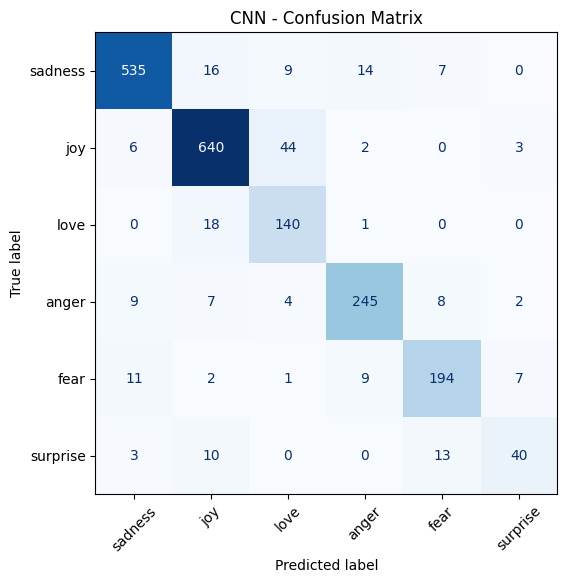

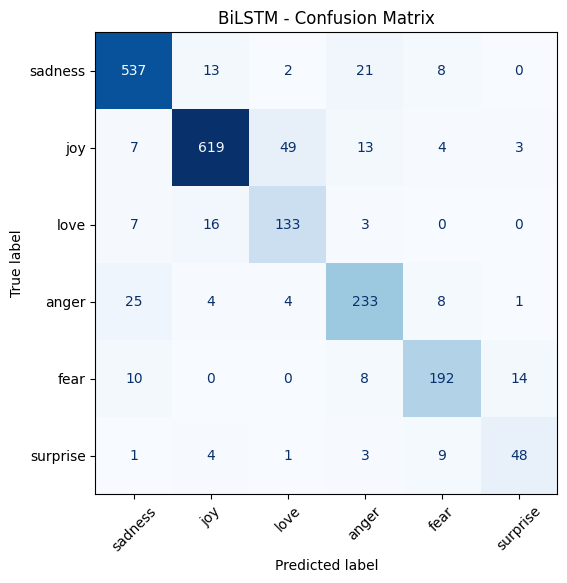

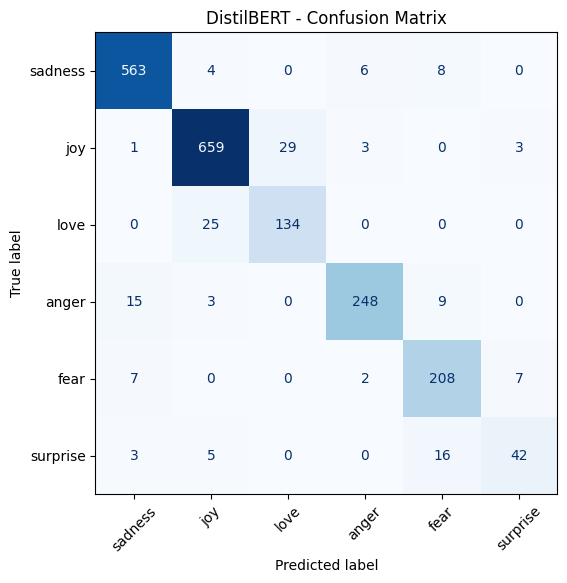

In [84]:
# Confusion matrices
plot_confusion(cnn_y_true, cnn_y_pred, label_names, "CNN - Confusion Matrix")
plot_confusion(bilstm_y_true, bilstm_y_pred, label_names, "BiLSTM - Confusion Matrix")
plot_confusion(transformer_y_true, transformer_y_pred, label_names, "DistilBERT - Confusion Matrix")


In [85]:
# Misclassified examples
print("CNN misclassified examples")
display(get_misclassified_examples(test_texts, cnn_y_true, cnn_y_pred, label_names, n=10))

print("BiLSTM misclassified examples")
display(get_misclassified_examples(test_texts, bilstm_y_true, bilstm_y_pred, label_names, n=10))

print("DistilBERT misclassified examples")
display(get_misclassified_examples(test_texts, transformer_y_true, transformer_y_pred, label_names, n=10))


CNN misclassified examples


,text,true_label,pred_label
0,i felt anger when at the end of a telephone call,anger,joy
1,i explain why i clung to a relationship with a...,joy,love
2,i don t feel particularly agitated,fear,anger
3,i pay attention it deepens into a feeling of b...,fear,sadness
4,im not sure the feeling of loss will ever go a...,sadness,love
5,i also tell you in hopes that anyone who is st...,sadness,joy
6,i had been talking to coach claudia barcomb an...,joy,love
7,i feel a bit stressed even though all the thin...,anger,sadness
8,i think they have always been proponents of th...,joy,sadness
9,i am right handed however i play billiards lef...,surprise,fear


BiLSTM misclassified examples


,text,true_label,pred_label
0,i explain why i clung to a relationship with a...,joy,love
1,i pay attention it deepens into a feeling of b...,fear,anger
2,i feel just bcoz a fight we get mad to each ot...,anger,fear
3,im not sure the feeling of loss will ever go a...,sadness,joy
4,i feel a bit stressed even though all the thin...,anger,sadness
5,i think they have always been proponents of th...,joy,love
6,i am right handed however i play billiards lef...,surprise,fear
7,i feel like i am in paradise kissing those swe...,joy,love
8,im feeling angry at someone i do something tho...,anger,love
9,i feel needy but comfortable with it i feel vu...,sadness,fear


DistilBERT misclassified examples


,text,true_label,pred_label
0,i don t feel particularly agitated,fear,anger
1,i feel if i completely hated things i d exerci...,anger,sadness
2,i feel a bit stressed even though all the thin...,anger,sadness
3,i am right handed however i play billiards lef...,surprise,fear
4,i feel like i am in paradise kissing those swe...,joy,love
5,i was feeling weird the other day and it went ...,fear,surprise
6,when a friend dropped a frog down my neck,anger,fear
7,i feel my heart is tortured by what i have done,anger,fear
8,im feeling generous today heres one more you m...,love,joy
9,i actually feel agitated which led to a terrib...,anger,fear


# 6. Model comparison
This section consolidates **all final comparisons in one place** so the results are easier to read:
- an overall comparison across **CNN**, **BiLSTM**, and the **selected DistilBERT strategy**
- a focused comparison of the three **DistilBERT transfer-learning strategies**
- visual summaries for performance, efficiency, and trade-offs


In [86]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def summarize_model(model_name, y_true, y_pred, training_time_sec, extra_info=None):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    accuracy = accuracy_score(y_true, y_pred)

    row = {
        "Model": model_name,
        "Precision": precision,
        "Recall": recall,
        "Macro F1": f1,
        "Accuracy": accuracy,
        "Training Time (sec)": training_time_sec
    }

    if extra_info is not None:
        row.update(extra_info)

    return row

overall_comparison_df = pd.DataFrame([
    summarize_model("TextCNN", cnn_y_true, cnn_y_pred, cnn_train_time),
    summarize_model("BiLSTM", bilstm_y_true, bilstm_y_pred, bilstm_train_time),
    summarize_model(
        best_transformer_strategy_label,
        transformer_y_true,
        transformer_y_pred,
        transformer_train_time,
        extra_info={
            "Transformer strategy": best_transformer_strategy_label,
            "Trainable Params": best_transformer_bundle["trainable_params"],
            "Total Params": best_transformer_bundle["total_params"]
        }
    )
])

overall_comparison_df = overall_comparison_df.sort_values(
    by=["Macro F1", "Accuracy"], ascending=False
).reset_index(drop=True)

overall_comparison_df["Rank by Macro F1"] = overall_comparison_df["Macro F1"].rank(
    ascending=False, method="dense"
).astype(int)
overall_comparison_df["Rank by Accuracy"] = overall_comparison_df["Accuracy"].rank(
    ascending=False, method="dense"
).astype(int)
overall_comparison_df["Rank by Speed"] = overall_comparison_df["Training Time (sec)"].rank(
    ascending=True, method="dense"
).astype(int)

display(
    overall_comparison_df.style
    .format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Accuracy": "{:.4f}",
        "Training Time (sec)": "{:.2f}",
        "Trainable Params": "{:,.0f}",
        "Total Params": "{:,.0f}"
    })
    .set_caption("Overall comparison across the final selected models")
)

,Model,Precision,Recall,Macro F1,Accuracy,Training Time (sec),Transformer strategy,Trainable Params,Total Params,Rank by Macro F1,Rank by Accuracy,Rank by Speed
0,DistilBERT (Full Fine-tune),0.8922,0.8711,0.8796,0.9270,308.72,DistilBERT (Full Fine-tune),"66,958,086","66,958,086",1,1,3
1,TextCNN,0.8544,0.8475,0.8477,0.8970,17.96,nan,nan,nan,2,2,1
2,BiLSTM,0.8312,0.8472,0.8381,0.8810,66.40,nan,nan,nan,3,3,2


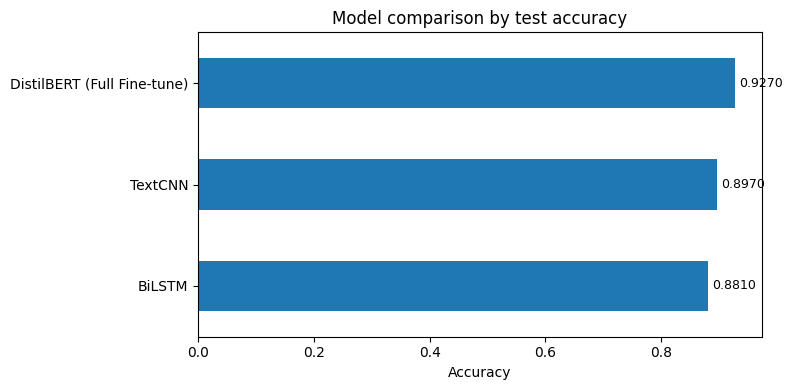

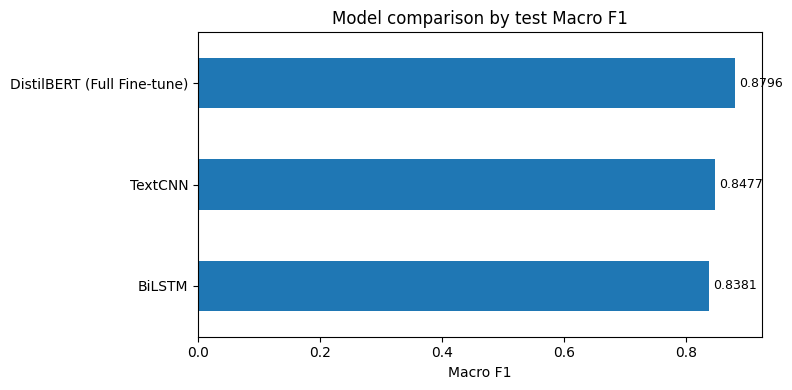

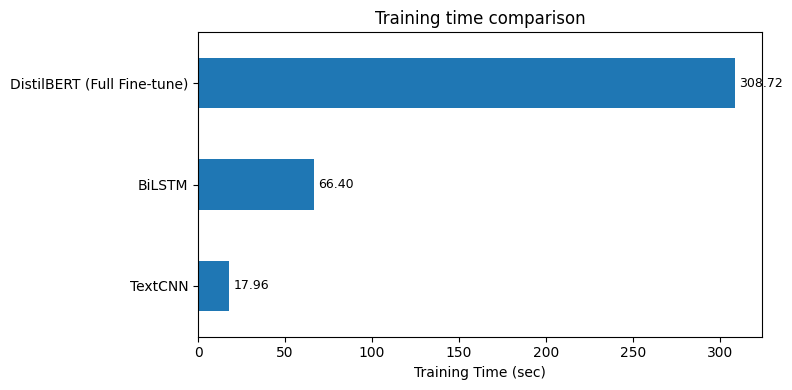

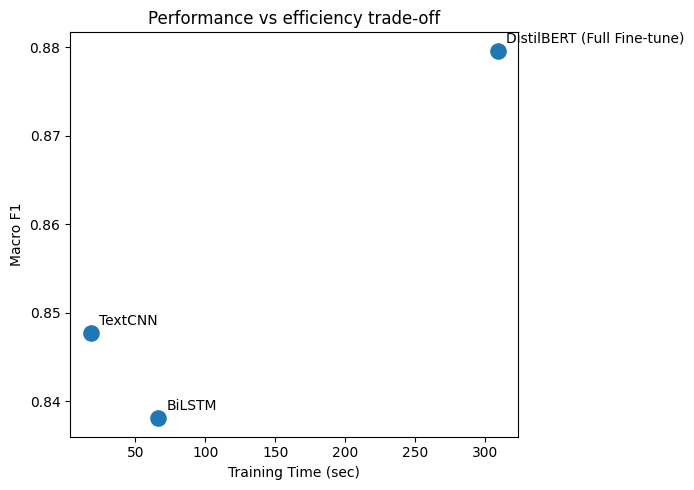

In [87]:
def add_bar_labels(ax, decimals=4):
    for container in ax.containers:
        labels = []
        for bar in container:
            value = bar.get_width() if bar.get_width() != 0 else bar.get_height()
            labels.append(f"{value:.{decimals}f}")
        ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plot_df = overall_comparison_df.copy()

ax = plot_df.sort_values("Accuracy", ascending=True).plot(
    x="Model", y="Accuracy", kind="barh", legend=False, figsize=(8, 4),
    title="Model comparison by test accuracy"
)
ax.set_xlabel("Accuracy")
ax.set_ylabel("")
add_bar_labels(ax, decimals=4)
plt.tight_layout()
plt.show()

ax = plot_df.sort_values("Macro F1", ascending=True).plot(
    x="Model", y="Macro F1", kind="barh", legend=False, figsize=(8, 4),
    title="Model comparison by test Macro F1"
)
ax.set_xlabel("Macro F1")
ax.set_ylabel("")
add_bar_labels(ax, decimals=4)
plt.tight_layout()
plt.show()

ax = plot_df.sort_values("Training Time (sec)", ascending=True).plot(
    x="Model", y="Training Time (sec)", kind="barh", legend=False, figsize=(8, 4),
    title="Training time comparison"
)
ax.set_xlabel("Training Time (sec)")
ax.set_ylabel("")
add_bar_labels(ax, decimals=2)
plt.tight_layout()
plt.show()

tradeoff_df = plot_df.copy()
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(tradeoff_df["Training Time (sec)"], tradeoff_df["Macro F1"], s=120)

for _, row in tradeoff_df.iterrows():
    ax.annotate(
        row["Model"],
        (row["Training Time (sec)"], row["Macro F1"]),
        textcoords="offset points",
        xytext=(6, 6)
    )

ax.set_xlabel("Training Time (sec)")
ax.set_ylabel("Macro F1")
ax.set_title("Performance vs efficiency trade-off")
plt.tight_layout()
plt.show()

## 6.1 DistilBERT strategy comparison

The notebook internally trains three Transformer strategies, but their comparison is shown only here for clarity:
- **Freeze backbone**
- **Partial fine-tune**
- **Full fine-tune**

The strategy with the best **validation Macro F1** is used as the final Transformer model in the overall comparison above.


,Strategy Key,Strategy,Trainable Params,Total Params,Val Accuracy,Val Macro F1,Test Accuracy,Test Macro F1,Training Time (sec)
0,full_finetune,DistilBERT (Full Fine-tune),"66,958,086","66,958,086",0.9410,0.9177,0.9270,0.8796,308.72
1,partial_finetune,DistilBERT (Partial Fine-tune),"7,683,078","66,958,086",0.8445,0.8121,0.8340,0.7764,113.58
2,freeze_backbone,DistilBERT (Freeze Backbone),"595,206","66,958,086",0.5020,0.2048,0.4950,0.2006,93.13


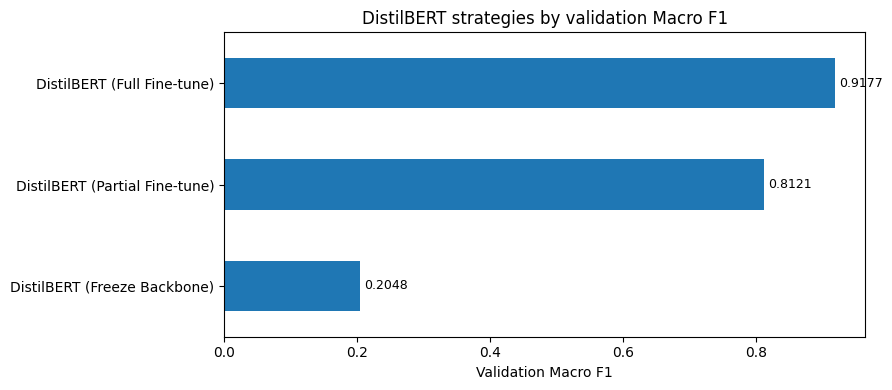

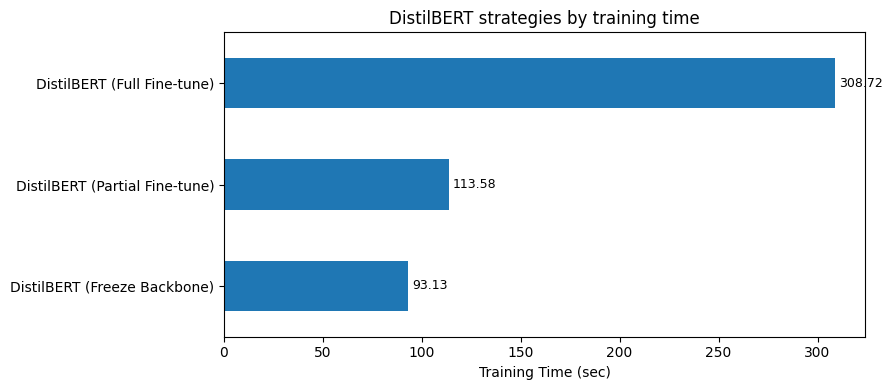

Selected DistilBERT strategy: DistilBERT (Full Fine-tune)
Validation Macro F1: 0.9177
Test Accuracy: 0.927
Test Macro F1: 0.8796
Trainable Params: 66,958,086
Training Time (sec): 308.72


In [88]:
transformer_strategy_view = transformer_strategy_results_df.copy()

display(
    transformer_strategy_view.style
    .format({
        "Val Accuracy": "{:.4f}",
        "Val Macro F1": "{:.4f}",
        "Test Accuracy": "{:.4f}",
        "Test Macro F1": "{:.4f}",
        "Training Time (sec)": "{:.2f}",
        "Trainable Params": "{:,.0f}",
        "Total Params": "{:,.0f}"
    })
    .set_caption("DistilBERT transfer-learning strategy comparison")
)

ax = transformer_strategy_view.sort_values("Val Macro F1", ascending=True).plot(
    x="Strategy", y="Val Macro F1", kind="barh", legend=False, figsize=(9, 4),
    title="DistilBERT strategies by validation Macro F1"
)
ax.set_xlabel("Validation Macro F1")
ax.set_ylabel("")
add_bar_labels(ax, decimals=4)
plt.tight_layout()
plt.show()

ax = transformer_strategy_view.sort_values("Training Time (sec)", ascending=True).plot(
    x="Strategy", y="Training Time (sec)", kind="barh", legend=False, figsize=(9, 4),
    title="DistilBERT strategies by training time"
)
ax.set_xlabel("Training Time (sec)")
ax.set_ylabel("")
add_bar_labels(ax, decimals=2)
plt.tight_layout()
plt.show()

selected_strategy_row = transformer_strategy_view.iloc[0]
print("Selected DistilBERT strategy:", selected_strategy_row["Strategy"])
print("Validation Macro F1:", round(selected_strategy_row["Val Macro F1"], 4))
print("Test Accuracy:", round(selected_strategy_row["Test Accuracy"], 4))
print("Test Macro F1:", round(selected_strategy_row["Test Macro F1"], 4))
print("Trainable Params:", f'{int(selected_strategy_row["Trainable Params"]):,}')
print("Training Time (sec):", round(float(selected_strategy_row["Training Time (sec)"]), 2))

In [89]:
best_f1_model = overall_comparison_df.loc[overall_comparison_df["Macro F1"].idxmax(), "Model"]
best_acc_model = overall_comparison_df.loc[overall_comparison_df["Accuracy"].idxmax(), "Model"]
fastest_model = overall_comparison_df.loc[overall_comparison_df["Training Time (sec)"].idxmin(), "Model"]

print(f"Best model by Macro F1: {best_f1_model}")
print(f"Best model by Accuracy: {best_acc_model}")
print(f"Fastest model to train: {fastest_model}")

Best model by Macro F1: DistilBERT (Full Fine-tune)
Best model by Accuracy: DistilBERT (Full Fine-tune)
Fastest model to train: TextCNN


### 6.2 F1-score by label

The following table and chart compare class-wise F1-scores across the three final models. This makes it easier to see which emotions are consistently difficult and which model is strongest on each label.


Model,BiLSTM,DistilBERT,TextCNN
Label,,,
sadness,0.9195,0.9624,0.9345
joy,0.9164,0.9475,0.9222
love,0.7644,0.8323,0.7843
anger,0.8381,0.9288,0.8974
fear,0.8629,0.8946,0.8700
surprise,0.7273,0.7119,0.6780


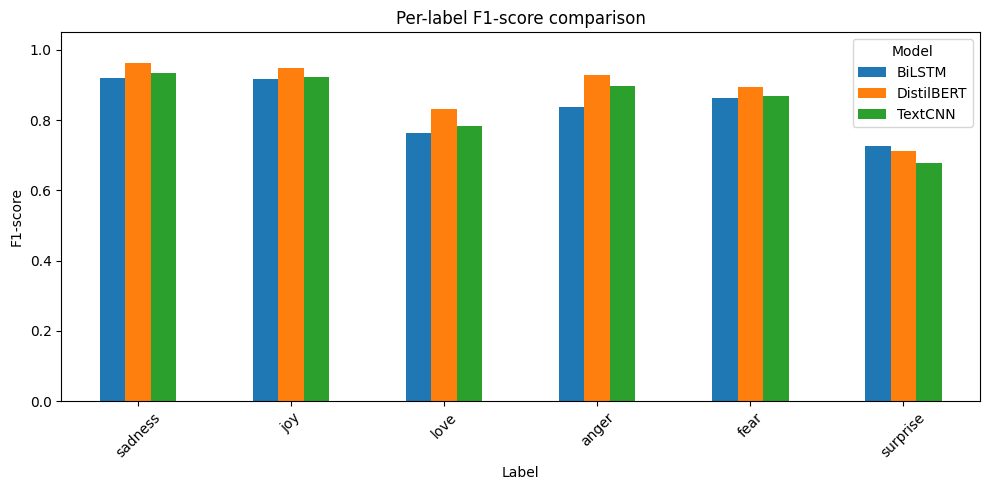

In [90]:

def per_label_f1_frame(y_true, y_pred, model_name):
    precision, recall, f1_scores, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(len(label_names))),
        average=None,
        zero_division=0
    )
    return pd.DataFrame({
        "Label": label_names,
        "F1": f1_scores,
        "Model": model_name,
        "Support": support
    })

per_label_f1_df = pd.concat([
    per_label_f1_frame(cnn_y_true, cnn_y_pred, "TextCNN"),
    per_label_f1_frame(bilstm_y_true, bilstm_y_pred, "BiLSTM"),
    per_label_f1_frame(transformer_y_true, transformer_y_pred, "DistilBERT")
], ignore_index=True)

per_label_f1_pivot = per_label_f1_df.pivot(index="Label", columns="Model", values="F1").reindex(label_names)
display(per_label_f1_pivot.round(4))

ax = per_label_f1_pivot.plot(kind="bar", figsize=(10, 5))
ax.set_title("Per-label F1-score comparison")
ax.set_xlabel("Label")
ax.set_ylabel("F1-score")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6.3 Learning curves

These plots compare how the models evolve during training. For CNN and BiLSTM, the curves come from the custom history lists. For DistilBERT, the curves are extracted from the Trainer log history of the selected strategy.


,epoch,loss,eval_loss,eval_accuracy,eval_f1_macro
0,1.0,0.475069,0.209949,0.9225,0.892314
1,2.0,0.151405,0.171154,0.9360,0.907408
2,3.0,0.101880,0.148656,0.9410,0.917699


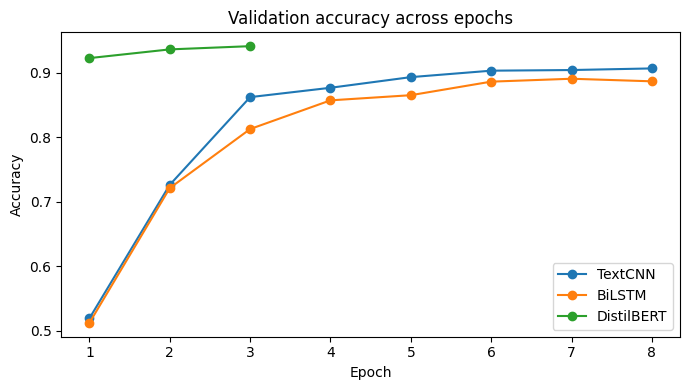

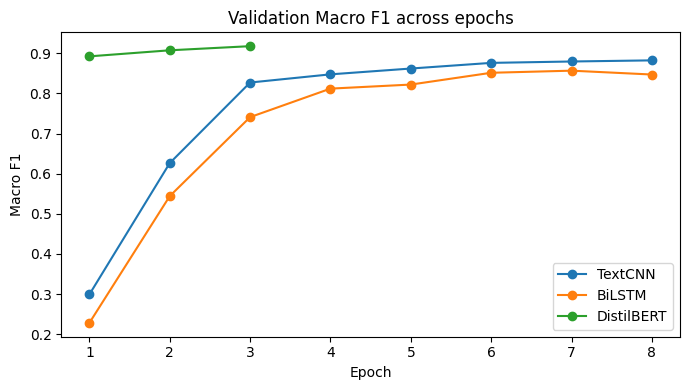

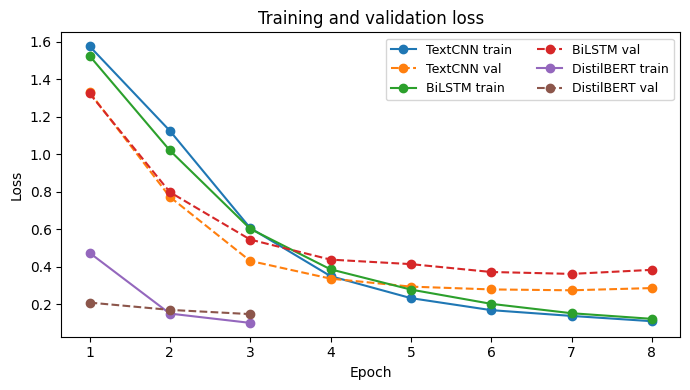

In [91]:
def build_transformer_history_df(log_history):
    epoch_map = {}
    for entry in log_history:
        epoch = entry.get("epoch", None)
        if epoch is None:
            continue
        epoch = float(epoch)
        if epoch not in epoch_map:
            epoch_map[epoch] = {"epoch": epoch}
        for key in ["loss", "eval_loss", "eval_accuracy", "eval_f1_macro"]:
            if key in entry:
                epoch_map[epoch][key] = entry[key]
    transformer_history_df = pd.DataFrame([epoch_map[e] for e in sorted(epoch_map.keys())])
    return transformer_history_df

transformer_history_df = build_transformer_history_df(best_transformer_bundle["log_history"])
display(transformer_history_df)

plt.figure(figsize=(7, 4))
plt.plot(cnn_history_df["epoch"], cnn_history_df["val_accuracy"], marker="o", label="TextCNN")
plt.plot(bilstm_history_df["epoch"], bilstm_history_df["val_accuracy"], marker="o", label="BiLSTM")
if "eval_accuracy" in transformer_history_df.columns:
    plt.plot(transformer_history_df["epoch"], transformer_history_df["eval_accuracy"], marker="o", label="DistilBERT")
plt.title("Validation accuracy across epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(cnn_history_df["epoch"], cnn_history_df["val_f1_macro"], marker="o", label="TextCNN")
plt.plot(bilstm_history_df["epoch"], bilstm_history_df["val_f1_macro"], marker="o", label="BiLSTM")
if "eval_f1_macro" in transformer_history_df.columns:
    plt.plot(transformer_history_df["epoch"], transformer_history_df["eval_f1_macro"], marker="o", label="DistilBERT")
plt.title("Validation Macro F1 across epochs")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(cnn_history_df["epoch"], cnn_history_df["train_loss"], marker="o", label="TextCNN train")
plt.plot(cnn_history_df["epoch"], cnn_history_df["val_loss"], marker="o", linestyle="--", label="TextCNN val")
plt.plot(bilstm_history_df["epoch"], bilstm_history_df["train_loss"], marker="o", label="BiLSTM train")
plt.plot(bilstm_history_df["epoch"], bilstm_history_df["val_loss"], marker="o", linestyle="--", label="BiLSTM val")
if "loss" in transformer_history_df.columns:
    plt.plot(transformer_history_df["epoch"], transformer_history_df["loss"], marker="o", label="DistilBERT train")
if "eval_loss" in transformer_history_df.columns:
    plt.plot(transformer_history_df["epoch"], transformer_history_df["eval_loss"], marker="o", linestyle="--", label="DistilBERT val")
plt.title("Training and validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

# 7 Conclusion

- **CNN** is the lightest baseline and trains quickly.
- **BiLSTM** adds a genuine RNN-based baseline for sequential modeling.
- **DistilBERT** is usually the strongest single model, but also the most expensive.
- **Ensemble (CNN + DistilBERT)** may further improve accuracy/F1 by combining local n-gram features from CNN with contextual representations from DistilBERT.
- The confusion matrices and misclassified examples help explain **where each model fails** and which emotion pairs are frequently confused.